In [1]:
!pip install -q ifcopenshell pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 MB 16.8 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()
ifc_filename = next(iter(uploaded))

print("Uploaded IFC file:", ifc_filename)

Saving IFC Schependomlaan.ifc to IFC Schependomlaan.ifc
Uploaded IFC file: IFC Schependomlaan.ifc


In [3]:
import ifcopenshell
import ifcopenshell.util.element
import pandas as pd

model = ifcopenshell.open(ifc_filename)

print("IFC schema:", model.schema)
print("Projects:", len(model.by_type("IfcProject")))
print("Buildings:", len(model.by_type("IfcBuilding")))
print("Storeys:", len(model.by_type("IfcBuildingStorey")))
print("Elements:", len(model.by_type("IfcElement")))

IFC schema: IFC2X3
Projects: 1
Buildings: 1
Storeys: 6
Elements: 3714


In [4]:
elements = model.by_type("IfcElement")
records = []

for element in elements:

    # Find the building storey containing the element
    try:
        storey = ifcopenshell.util.element.get_container(
            element,
            ifc_class="IfcBuildingStorey"
        )
        storey_name = storey.Name if storey else None
    except Exception:
        storey_name = None

    # Find the element type
    try:
        element_type = ifcopenshell.util.element.get_type(element)
        type_name = element_type.Name if element_type else None
    except Exception:
        type_name = None

    records.append({
        "GUID": element.GlobalId,
        "IfcClass": element.is_a(),
        "ElementName": getattr(element, "Name", None),
        "Description": getattr(element, "Description", None),
        "ObjectType": getattr(element, "ObjectType", None),
        "Tag": getattr(element, "Tag", None),
        "TypeName": type_name,
        "BuildingStorey": storey_name,
        "HasGeometry": getattr(element, "Representation", None) is not None
    })

ifc_elements = pd.DataFrame(records)

print("Extracted elements:", len(ifc_elements))
display(ifc_elements.head())

Extracted elements: 3714


,GUID,IfcClass,ElementName,Description,ObjectType,Tag,TypeName,BuildingStorey,HasGeometry
0,3vSAOyJwTEhQMEIJ6D9qRY,IfcBeam,liftputwand,None,IFC_betonopstort_220x345 220 x 345,F970A63C-4FA7-4EAD-A58E-49318D2746E2,IFC_betonopstort_220x345 220 x 345,-1 fundering,True
1,1a49H1hof5wg_s62YvIj$u,IfcBeam,fund_strook,None,IFC_strookfundering_2600x550 2600 x 550,64109441-AF2A-45EA-AFB6-1828B94ADFF8,IFC_strookfundering_2600x550 2600 x 550,-1 fundering,True
2,2501ntWb95m8MEJo4qrYny,IfcBeam,fund_opstort,None,IFC_betonopstort_220x315 220 x 315,85001C77-8252-45C0-858E-4F2134D62C7C,IFC_betonopstort_220x315 220 x 315,-1 fundering,True
3,1HNUZLqr52MQIS8JLIpeyr,IfcBeam,fund_opstort,None,IFC_betonopstort_370x315 370 x 315,515DE8D5-D351-4259-A49C-213552CE8F35,IFC_betonopstort_370x315 370 x 315,-1 fundering,True
4,3yL4PuBWf5GQngGRpOzQj0,IfcBeam,fund_opstort,None,IFC_betonopstort_220x315 220 x 315,FC544678-2E0A-4541-AC6A-41BCD8F5AB40,IFC_betonopstort_220x315 220 x 315,-1 fundering,True


In [5]:
class_summary = (
    ifc_elements["IfcClass"]
    .value_counts()
    .rename_axis("IfcClass")
    .reset_index(name="ElementCount")
)

display(class_summary.head(20))

,IfcClass,ElementCount
0,IfcCovering,1262
1,IfcWall,652
2,IfcWallStandardCase,282
3,IfcSlab,279
4,IfcBuildingElementPart,277
5,IfcWindow,259
6,IfcDoor,205
7,IfcBeam,174
8,IfcRailing,90
9,IfcOpeningElement,79


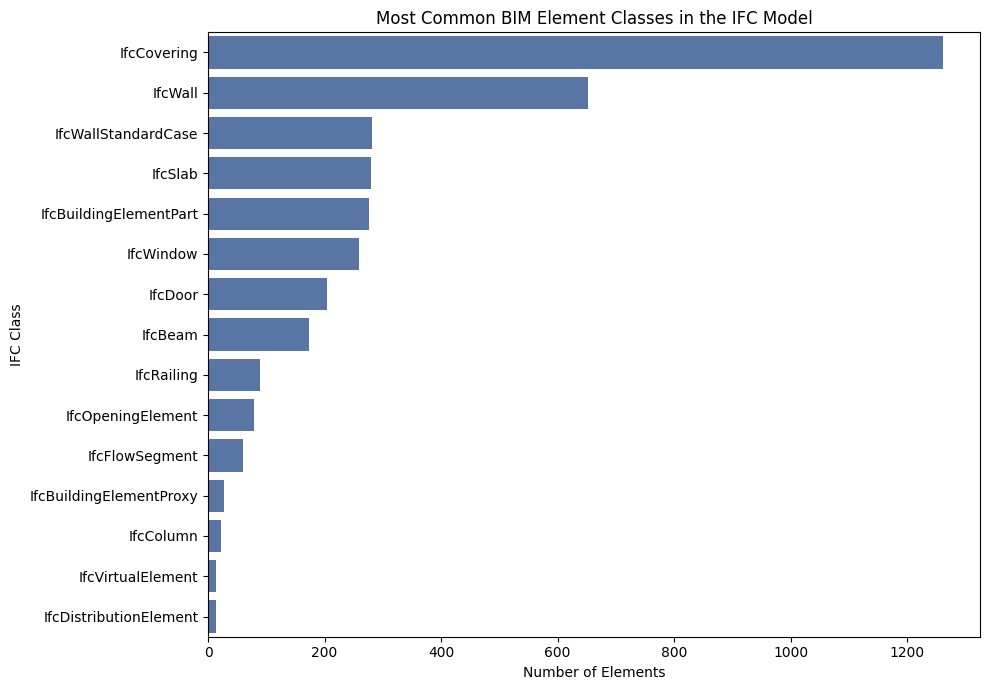

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

top_classes = class_summary.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_classes,
    x="ElementCount",
    y="IfcClass",
    color="#4C72B0"
)

plt.title("Most Common BIM Element Classes in the IFC Model")
plt.xlabel("Number of Elements")
plt.ylabel("IFC Class")
plt.tight_layout()
plt.show()

In [7]:
print("Total extracted elements:", len(ifc_elements))
print("Unique GUIDs:", ifc_elements["GUID"].nunique())
print("Missing GUIDs:", ifc_elements["GUID"].isna().sum())
print("Duplicated GUIDs:", ifc_elements["GUID"].duplicated().sum())

Total extracted elements: 3714
Unique GUIDs: 3714
Missing GUIDs: 0
Duplicated GUIDs: 0


In [8]:
ifc_elements.to_csv(
    "ifc_elements_extracted.csv",
    index=False
)

files.download("ifc_elements_extracted.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>